# Entrenamiento y regularización: que la red generalice

> Cómo diagnosticar el sobreajuste de una red neuronal a partir de las curvas de entrenamiento y validación y qué hacer: penalización de pesos (*weight decay*), *dropout*, parada temprana, aumento de datos, normalización por lotes, programación de la tasa de aprendizaje y búsqueda de hiperparámetros. Qué ayuda de verdad y qué mejora menos de lo que parece.
>
> **Requisitos previos:** [Redes neuronales densas](01-redes-neuronales-densas.ipynb) · **Relacionado:** [Flujo de ML y evaluación](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb) · [Redes convolucionales](03-redes-convolucionales.ipynb)

## 1. Idea clave

Una red neuronal tiene tanta capacidad que puede **memorizar** el conjunto de entrenamiento: la pérdida de entrenamiento baja casi a cero mientras la de validación empieza a subir. Es el **sobreajuste** (*overfitting*) y se diagnostica comparando las curvas de entrenamiento y validación, no mirando solo la exactitud final. La **regularización** reúne las técnicas que reducen esa brecha: penalizar pesos grandes, apagar neuronas al azar (*dropout*), parar cuando la validación deja de mejorar, ampliar los datos con transformaciones, normalizar las activaciones y ajustar bien la tasa de aprendizaje.

Ninguna técnica es una receta mágica. Aquí se comparan sobre el mismo problema y se verá que reducen el sobreajuste (la brecha entre entrenamiento y validación y, sobre todo, la **pérdida** de validación) con una mejora de exactitud mucho menor y, a veces, dentro del ruido entre ejecuciones. Por eso cada decisión se mide en validación, con varias semillas, y el test se mira una sola vez.

## 2. Conceptos importantes

### 2.1. Diagnóstico: curvas de entrenamiento y validación

Se dibujan la pérdida (y la exactitud) de entrenamiento y de validación época a época:

| Síntoma | Diagnóstico | Qué probar |
|---|---|---|
| Ambas pérdidas altas y cercanas | **Subajuste**: poca capacidad o poco entrenamiento | Red más grande, más épocas, mayor tasa de aprendizaje |
| Entrenamiento baja, validación baja y luego **sube** | **Sobreajuste** | Más datos o aumento de datos, regularización, red más pequeña, parada temprana |
| Ambas bajan y se estabilizan juntas | Buen ajuste | Seguir; ajustar hiperparámetros |
| La pérdida oscila o diverge | Tasa de aprendizaje demasiado alta o datos sin normalizar | Bajarla; normalizar entradas |

La pérdida de validación es más sensible que la exactitud: puede empeorar (el modelo se vuelve **demasiado seguro** de sus errores) mientras la exactitud casi no cambia.

### 2.2. Penalización de pesos (*weight decay*, regularización L2)

Se añade a la pérdida un término que penaliza los pesos grandes: $L'(\theta)=L(\theta)+\frac{\lambda}{2}\lVert\theta\rVert^2$. El paso de descenso queda

$$
\theta\leftarrow\theta(1-\eta\lambda)-\eta\,\nabla L,
$$

es decir, los pesos **decaen** un poco en cada paso. Prefiere soluciones con pesos pequeños, que dan funciones más suaves y menos sensibles al ruido. Con Adam, penalizar en la pérdida no equivale a decaer los pesos (el denominador adaptativo reescala el término); **AdamW** aplica el decaimiento de forma separada (*decoupled*) y es la forma recomendada de usarlo. Suele aplicarse a los pesos y no a los sesgos.

### 2.3. *Dropout*

Durante el **entrenamiento**, cada neurona de una capa se apaga con probabilidad $p$ (su salida pasa a 0) y las supervivientes se multiplican por $1/(1-p)$ para conservar la escala (*inverted dropout*). Obliga a que ninguna neurona dependa de otras concretas (evita la **co-adaptación**) y se interpreta como entrenar un conjunto enorme de subredes que comparten pesos. En **evaluación** no se apaga nada. Valores típicos: $p=0{,}1$–$0{,}5$ (más alto en capas grandes).

### 2.4. Parada temprana (*early stopping*)

Se mide la pérdida de validación en cada época, se guarda el mejor modelo y se detiene el entrenamiento cuando no mejora durante $k$ épocas (la **paciencia**). Después se restauran los mejores pesos. Cuesta casi nada y evita decidir "a ojo" el número de épocas.

### 2.5. Aumento de datos (*data augmentation*)

Se generan ejemplos de entrenamiento nuevos aplicando transformaciones que **no cambian la etiqueta** (en imágenes: volteos, recortes, giros pequeños, cambios de brillo). Es como tener más datos. Solo se aplica al entrenamiento (nunca a validación ni test) y debe tener sentido para el problema: voltear horizontalmente una prenda es válido, voltear un "6" no (se parece a otro dígito).

### 2.6. Normalización por lotes (*batch normalization*)

Normaliza las activaciones de cada neurona con la media $\mu_B$ y la varianza $\sigma_B^2$ del lote, y después las reescala con parámetros aprendidos $\gamma,\beta$:

$$
\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},\qquad y=\gamma\hat{x}+\beta.
$$

Estabiliza el entrenamiento, permite tasas de aprendizaje mayores y actúa como una regularización suave (el ruido de las estadísticas del lote). En evaluación usa medias y varianzas **móviles** acumuladas durante el entrenamiento, así que el modelo se comporta distinto en modo `train` y `eval`.

### 2.7. Programación de la tasa de aprendizaje

Una tasa fija suele ser demasiado alta al final (el modelo oscila alrededor del mínimo) o demasiado baja al principio. Se **reduce** a lo largo del entrenamiento: por pasos (*step decay*), con una curva de coseno (*cosine annealing*, de $\eta_0$ a casi 0), o cuando la validación se estanca (`ReduceLROnPlateau`). A veces se empieza con unas pocas iteraciones de **calentamiento** (*warm-up*) con tasa creciente.

### 2.8. Búsqueda de hiperparámetros

La **búsqueda en rejilla** prueba todas las combinaciones de unos valores fijados y se vuelve inabordable al crecer el número de hiperparámetros. La **búsqueda aleatoria** muestrea combinaciones al azar y suele ser más eficiente, porque normalmente solo unos pocos hiperparámetros importan mucho y así cada prueba explora valores distintos de ellos. La tasa de aprendizaje y el decaimiento de pesos se muestrean en **escala logarítmica**. Librerías como Optuna usan métodos más inteligentes (optimización bayesiana, p. ej. TPE) que aprovechan los resultados anteriores. Siempre se elige con **validación**, nunca con el test.

## 3. Código

Para ver el sobreajuste en segundos, entrenamos con **3 000 imágenes** de Fashion-MNIST (las mismas de [la red densa](01-redes-neuronales-densas.ipynb), con la misma estandarización), una red grande (dos capas ocultas de 512 neuronas, 669 706 parámetros: muchos más que ejemplos) y validamos con 10 000 imágenes distintas. Es una situación de **pocos datos y mucha capacidad**, justo donde la regularización importa. El test (10 000 imágenes) se usará una sola vez al final.

In [1]:
import contextlib
import copy
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

device = "cuda" if torch.cuda.is_available() else "cpu"

### 3.1. Datos

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    entrenamiento = datasets.FashionMNIST("data", train=True, download=True)
    prueba = datasets.FashionMNIST("data", train=False, download=True)

X = entrenamiento.data.float().div(255)
media, desv = X.mean(), X.std()
X = ((X - media) / desv).view(-1, 784)
y = entrenamiento.targets
X_test = ((prueba.data.float().div(255) - media) / desv).view(-1, 784)
y_test = prueba.targets

orden = torch.randperm(len(X), generator=torch.Generator().manual_seed(42))
X_train, y_train = X[orden[:3000]], y[orden[:3000]]
X_val, y_val = X[orden[50000:]], y[orden[50000:]]
print(f"entrenamiento {tuple(X_train.shape)}, validación {tuple(X_val.shape)}, test {tuple(X_test.shape)}")

entrenamiento (3000, 784), validación (10000, 784), test (10000, 784)


### 3.2. Un bucle de entrenamiento configurable

Ampliamos el de [la red densa](01-redes-neuronales-densas.ipynb) con lo necesario para este notebook: aumento de datos (un volteo horizontal aleatorio de cada imagen), planificador de la tasa de aprendizaje y **parada temprana** con restauración de los mejores pesos. En cada época registra la pérdida y la exactitud de entrenamiento y de validación (el modelo en modo evaluación).

In [3]:
def crear_mlp(ocultas=512, dropout=0.0, batchnorm=False):
    capas, n_in = [], 784
    for _ in range(2):
        capas.append(nn.Linear(n_in, ocultas))
        if batchnorm:
            capas.append(nn.BatchNorm1d(ocultas))
        capas.append(nn.ReLU())
        if dropout > 0:
            capas.append(nn.Dropout(dropout))
        n_in = ocultas
    return nn.Sequential(*capas, nn.Linear(n_in, 10))

def evaluar(modelo, X_, y_):
    modelo.eval()
    with torch.no_grad():
        logits = modelo(X_.to(device))
        return F.cross_entropy(logits, y_.to(device)).item(), (logits.argmax(1).cpu() == y_).float().mean().item()

def voltear(xb):                                         # volteo horizontal aleatorio de cada imagen
    imagenes = xb.view(-1, 28, 28)
    mascara = torch.rand(len(imagenes), device=xb.device) < 0.5
    return torch.where(mascara[:, None, None], imagenes.flip(2), imagenes).reshape(-1, 784)

def entrenar(modelo, optimizador, epocas=40, lote=64, aumento=False, paciencia=None, planificador=None, semilla=0):
    modelo.to(device)
    cargador = DataLoader(TensorDataset(X_train, y_train), batch_size=lote, shuffle=True, generator=torch.Generator().manual_seed(semilla))
    historial, mejor = [], {"pérdida": float("inf"), "pesos": None, "época": 0}
    for epoca in range(1, epocas + 1):
        modelo.train()
        for xb, yb in cargador:
            xb, yb = xb.to(device), yb.to(device)
            if aumento:
                xb = voltear(xb)
            optimizador.zero_grad()
            F.cross_entropy(modelo(xb), yb).backward()
            optimizador.step()
        if planificador:
            planificador.step()
        tr_perdida, tr_exactitud = evaluar(modelo, X_train, y_train)
        val_perdida, val_exactitud = evaluar(modelo, X_val, y_val)
        historial.append({"pérdida entrenamiento": tr_perdida, "pérdida validación": val_perdida,
                          "exactitud entrenamiento": tr_exactitud, "exactitud validación": val_exactitud})
        if val_perdida < mejor["pérdida"]:
            mejor = {"pérdida": val_perdida, "pesos": copy.deepcopy(modelo.state_dict()), "época": epoca}
        if paciencia and epoca - mejor["época"] >= paciencia:
            break
    return pd.DataFrame(historial, index=range(1, len(historial) + 1)), mejor

### 3.3. Sin regularización: el sobreajuste

Entrenamos 40 épocas con AdamW sin decaimiento de pesos (equivale a Adam).

Parámetros: 669706


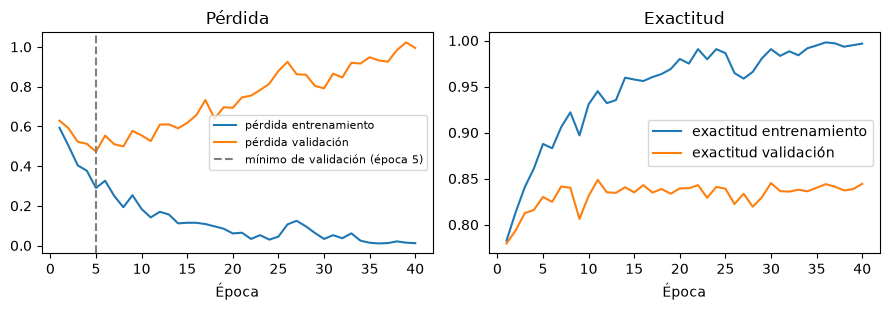

Mínimo de la pérdida de validación: 0.473 en la época 5; al final de las 40 épocas: 0.995
Exactitud al final: entrenamiento 0.997, validación 0.844


In [4]:
torch.manual_seed(0)
modelo_base = crear_mlp()
print("Parámetros:", sum(p.numel() for p in modelo_base.parameters()))
hist_base, mejor_base = entrenar(modelo_base, torch.optim.AdamW(modelo_base.parameters(), lr=1e-3, weight_decay=0.0))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
hist_base[["pérdida entrenamiento", "pérdida validación"]].plot(ax=axes[0])
axes[0].axvline(mejor_base["época"], color="gray", ls="--", label=f"mínimo de validación (época {mejor_base['época']})")
axes[0].legend(fontsize=8); axes[0].set_title("Pérdida"); axes[0].set_xlabel("Época")
hist_base[["exactitud entrenamiento", "exactitud validación"]].plot(ax=axes[1])
axes[1].set_title("Exactitud"); axes[1].set_xlabel("Época")
plt.tight_layout()
plt.show()
print(f"Mínimo de la pérdida de validación: {mejor_base['pérdida']:.3f} en la época {mejor_base['época']}; al final de las 40 épocas: {hist_base['pérdida validación'].iloc[-1]:.3f}")
print(f"Exactitud al final: entrenamiento {hist_base['exactitud entrenamiento'].iloc[-1]:.3f}, validación {hist_base['exactitud validación'].iloc[-1]:.3f}")

La pérdida de entrenamiento cae a ≈ 0 y la exactitud de entrenamiento llega al 99,7 %, pero la validación tiene su **mínimo muy pronto (época 5, pérdida 0,47)** y a partir de ahí **sube** hasta ≈ 1,0: la red memoriza los 3 000 ejemplos y se vuelve demasiado segura de sus errores. La exactitud en validación, en cambio, apenas se mueve (≈ 0,84): por eso la pérdida es la mejor señal para detectar el problema.

### 3.4. Comparación de técnicas

Mismas condiciones (40 épocas, 3 semillas por técnica) para: decaimiento de pesos (AdamW con $\lambda=1$), *dropout* ($p=0{,}5$ tras cada capa oculta), normalización por lotes, aumento de datos (volteo) y las tres combinadas (*dropout* + decaimiento + aumento). Medimos, al final del entrenamiento: exactitud de entrenamiento y de validación, pérdida de validación final y mínimo alcanzado en alguna época.

In [5]:
tecnicas = {
    "Sin regularización": dict(),
    "Decaimiento de pesos (λ=1)": dict(decaimiento=1.0),
    "Dropout (p=0,5)": dict(dropout=0.5),
    "Normalización por lotes": dict(batchnorm=True),
    "Aumento de datos (volteo)": dict(aumento=True),
    "Dropout + decaimiento + aumento": dict(dropout=0.5, decaimiento=1.0, aumento=True),
}
filas = {}
for nombre, cfg in tecnicas.items():
    resultados = []
    for semilla in range(3):
        torch.manual_seed(semilla)
        modelo = crear_mlp(dropout=cfg.get("dropout", 0.0), batchnorm=cfg.get("batchnorm", False))
        opt = torch.optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=cfg.get("decaimiento", 0.0))
        h, mejor = entrenar(modelo, opt, aumento=cfg.get("aumento", False), semilla=semilla)
        resultados.append({"exactitud entrenamiento": h["exactitud entrenamiento"].iloc[-1], "exactitud validación": h["exactitud validación"].iloc[-1],
                           "pérdida validación (final)": h["pérdida validación"].iloc[-1], "pérdida validación (mínima)": mejor["pérdida"]})
    r = pd.DataFrame(resultados)
    filas[nombre] = {c: f"{r[c].mean():.3f} ± {r[c].std():.3f}" for c in r.columns}
pd.DataFrame(filas).T

,exactitud entrenamiento,exactitud validación,pérdida validación (final),pérdida validación (mínima)
Sin regularización,0.996 ± 0.002,0.841 ± 0.005,0.955 ± 0.035,0.482 ± 0.008
Decaimiento de pesos (λ=1),0.949 ± 0.023,0.824 ± 0.013,0.657 ± 0.047,0.471 ± 0.012
"Dropout (p=0,5)",0.952 ± 0.007,0.848 ± 0.002,0.613 ± 0.018,0.465 ± 0.005
Normalización por lotes,0.994 ± 0.003,0.829 ± 0.001,0.924 ± 0.025,0.480 ± 0.004
Aumento de datos (volteo),0.979 ± 0.005,0.834 ± 0.008,0.908 ± 0.029,0.485 ± 0.013
Dropout + decaimiento + aumento,0.892 ± 0.007,0.834 ± 0.004,0.487 ± 0.008,0.454 ± 0.006


(Media ± desviación típica de 3 semillas.) Lo que se ve:

- La **brecha** entre entrenamiento y validación se cierra con las técnicas que limitan la capacidad: la exactitud de entrenamiento baja de 0,996 (sin regularizar) a 0,952 con *dropout* y a 0,892 con las tres combinadas, y la **pérdida de validación final** baja de 0,955 a 0,613 y a **0,487** (casi su mínimo, 0,454).
- La **exactitud de validación casi no cambia**: entre 0,824 y 0,848 frente a 0,841 sin regularizar, con desviaciones de 0,002 a 0,013. Solo el *dropout* (0,848 ± 0,002) mejora algo; el decaimiento de pesos con $\lambda=1$ (0,824) y la normalización por lotes (0,829) incluso empeoran. Con 3 semillas, diferencias de menos de ≈ 1 punto no son concluyentes.
- El **mínimo** de la pérdida de validación (0,45–0,49) es casi igual en todos los casos: la regularización no consigue un modelo mejor que el que ya existía en las primeras épocas del modelo sin regularizar, pero mantiene al modelo **cerca de ese mínimo** durante todo el entrenamiento, en vez de dejarlo degradarse. Eso es lo que hace también la parada temprana, gratis (3.5).

### 3.5. Parada temprana

Entrenamos el modelo sin regularizar y el combinado con paciencia de 10 épocas, restaurando los mejores pesos, y evaluamos en el **test** (una sola vez) junto al modelo sin regularizar entrenado 40 épocas completas.

In [6]:
filas = {}
for nombre, cfg, paciencia in [("Sin regularización, 40 épocas completas", dict(), None),
                               ("Sin regularización + parada temprana", dict(), 10),
                               ("Dropout + decaimiento + aumento + parada temprana", dict(dropout=0.5, decaimiento=1.0, aumento=True), 10)]:
    torch.manual_seed(0)
    modelo = crear_mlp(dropout=cfg.get("dropout", 0.0))
    opt = torch.optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=cfg.get("decaimiento", 0.0))
    h, mejor = entrenar(modelo, opt, epocas=100 if paciencia else 40, aumento=cfg.get("aumento", False), paciencia=paciencia)
    if paciencia:
        modelo.load_state_dict(mejor["pesos"])                # se restauran los mejores pesos
    test_perdida, test_exactitud = evaluar(modelo, X_test, y_test)
    filas[nombre] = {"épocas entrenadas": len(h), "mejor época": mejor["época"] if paciencia else len(h),
                     "pérdida test": test_perdida, "exactitud test": test_exactitud}
pd.DataFrame(filas).T.round(3)

,épocas entrenadas,mejor época,pérdida test,exactitud test
"Sin regularización, 40 épocas completas",40.0,40.0,1.047,0.841
Sin regularización + parada temprana,15.0,5.0,0.509,0.820
Dropout + decaimiento + aumento + parada temprana,38.0,28.0,0.485,0.830


La parada temprana detiene el modelo sin regularizar en la **época 15** (la mejor fue la 5): su pérdida en test (0,51) es la mitad de la del modelo entrenado las 40 épocas (1,05), pero su **exactitud es algo menor** (0,820 frente a 0,841). El modelo combinado con parada temprana tiene la mejor pérdida (0,485) y una exactitud de 0,830. Es decir, ninguna opción **mejora la exactitud** del modelo entrenado completo, con cuyo mismo resultado hay que comparar: lo que cambia es que las predicciones están mucho mejor calibradas (la red no se equivoca con tanta seguridad) y que no hay que decidir a ciegas cuántas épocas hacer. Si lo que importa es la probabilidad que da el modelo (y no solo la clase), la regularización sí compensa.

### 3.6. El modo de evaluación importa con *dropout*

Entrenamos un modelo con *dropout* y calculamos la exactitud de validación en modo `eval()` y, por error, en modo `train()`.

In [7]:
torch.manual_seed(0)
modelo = crear_mlp(dropout=0.5)
entrenar(modelo, torch.optim.AdamW(modelo.parameters(), lr=1e-3), epocas=20)
modelo.eval()
with torch.no_grad():
    exactitud_eval = (modelo(X_val.to(device)).argmax(1).cpu() == y_val).float().mean().item()
modelo.train()                                           # error: se deja el dropout activo al evaluar
with torch.no_grad():
    exactitud_train = (modelo(X_val.to(device)).argmax(1).cpu() == y_val).float().mean().item()
print(f"Exactitud de validación con model.eval():  {exactitud_eval:.3f}")
print(f"Exactitud de validación con model.train(): {exactitud_train:.3f}  (dropout activo al predecir)")

Exactitud de validación con model.eval():  0.837
Exactitud de validación con model.train(): 0.817  (dropout activo al predecir)


Dejar el *dropout* activo al predecir baja la exactitud (0,817 frente a 0,837) y además hace las predicciones **aleatorias** (dos ejecuciones dan resultados distintos). Con normalización por lotes el efecto es todavía peor: usaría las estadísticas del lote en lugar de las acumuladas.

### 3.7. Programación de la tasa de aprendizaje

Modelo con *dropout* y aumento, tasa inicial alta ($3\cdot10^{-3}$), tasa constante frente a *cosine annealing* (baja hasta casi 0 en 40 épocas), 3 semillas.

In [8]:
filas = {}
for nombre, usar_coseno in [("Tasa constante (3e-3)", False), ("Cosine annealing (de 3e-3 a 0)", True)]:
    exactitudes, perdidas = [], []
    for semilla in range(3):
        torch.manual_seed(semilla)
        modelo = crear_mlp(dropout=0.5)
        opt = torch.optim.AdamW(modelo.parameters(), lr=3e-3, weight_decay=0.1)
        plan = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=40) if usar_coseno else None
        h, _ = entrenar(modelo, opt, aumento=True, planificador=plan, semilla=semilla)
        exactitudes.append(h["exactitud validación"].iloc[-1]); perdidas.append(h["pérdida validación"].iloc[-1])
    filas[nombre] = {"exactitud validación": f"{np.mean(exactitudes):.3f} ± {np.std(exactitudes, ddof=1):.3f}",
                     "pérdida validación": f"{np.mean(perdidas):.3f} ± {np.std(perdidas, ddof=1):.3f}"}
pd.DataFrame(filas).T

,exactitud validación,pérdida validación
Tasa constante (3e-3),0.823 ± 0.009,0.550 ± 0.037
Cosine annealing (de 3e-3 a 0),0.849 ± 0.002,0.486 ± 0.005


Reducir la tasa a lo largo del entrenamiento mejora la exactitud en validación (de 0,823 a 0,849 con la misma tasa inicial de $3\cdot10^{-3}$) y baja la pérdida de validación de 0,55 a 0,49: al principio avanza rápido con pasos grandes y al final se asienta en el mínimo con pasos pequeños.

### 3.8. Búsqueda aleatoria de hiperparámetros

Muestreamos 12 combinaciones al azar de: tasa de aprendizaje (escala logarítmica entre $10^{-4}$ y $10^{-2}$), tasa de *dropout* (0, 0,2, 0,4, 0,6), neuronas ocultas (128, 256, 512, 1024) y decaimiento de pesos (escala logarítmica entre $10^{-4}$ y $10^{-1}$). Cada combinación se entrena 20 épocas y se compara por la exactitud en validación.

In [9]:
rng = np.random.default_rng(42)
pruebas = []
for _ in range(12):
    lr, decaimiento = 10 ** rng.uniform(-4, -2), 10 ** rng.uniform(-4, -1)
    dropout, ocultas = rng.choice([0.0, 0.2, 0.4, 0.6]), int(rng.choice([128, 256, 512, 1024]))
    torch.manual_seed(42)
    modelo = crear_mlp(ocultas=ocultas, dropout=dropout)
    h, _ = entrenar(modelo, torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=decaimiento), epocas=20)
    pruebas.append({"lr": lr, "dropout": dropout, "neuronas": ocultas, "decaimiento": decaimiento, "exactitud validación": h["exactitud validación"].iloc[-1]})
busqueda = pd.DataFrame(pruebas).sort_values("exactitud validación", ascending=False)
print("Mejores:"); print(busqueda.head(3).round(4).to_string(index=False))
print("Peores:"); print(busqueda.tail(3).round(4).to_string(index=False))
print(f"\nRango de exactitudes: {busqueda['exactitud validación'].min():.3f} – {busqueda['exactitud validación'].max():.3f}")

Mejores:
    lr  dropout  neuronas  decaimiento  exactitud validación
0.0005      0.2      1024       0.0817                0.8485
0.0001      0.4       512       0.0003                0.8420
0.0008      0.0      1024       0.0013                0.8383
Peores:
    lr  dropout  neuronas  decaimiento  exactitud validación
0.0003      0.6       128       0.0046                0.8141
0.0033      0.4       128       0.0228                0.8140
0.0045      0.0      1024       0.0079                0.8010

Rango de exactitudes: 0.801 – 0.849


Las combinaciones van de 0,801 a 0,849 de exactitud en validación: la elección importa, pero **mucho menos que los datos**. La mejor (tasa de aprendizaje $5\cdot10^{-4}$, *dropout* 0,2, 1 024 neuronas y decaimiento 0,08) combina una tasa moderada con algo de regularización; la peor tiene una tasa alta ($4{,}5\cdot10^{-3}$) sin *dropout* y con una red grande, y otras malas combinan mucho *dropout* con una red pequeña (0,6 con 128 neuronas). Doce pruebas son pocas para una conclusión firme (la diferencia entre la mejor y la segunda, 0,6 puntos, está dentro del ruido entre semillas): con más presupuesto se usa una librería de optimización (Optuna) o se refina la búsqueda en torno a las mejores. La combinación elegida se evaluaría **una vez** en el test.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Valores típicos / consejo |
|---|---|---|
| `weight_decay` (AdamW) | Fuerza del decaimiento de pesos $\lambda$ | `1e-4`–`1e-1` con AdamW (probar en escala log.); un valor demasiado alto causa subajuste (3.4: $\lambda=1$ empeora) |
| `nn.Dropout(p)` | Probabilidad de apagar una neurona | 0,1–0,5; más alto cuanto más grande es la capa; cuesta convergencia (necesita más épocas) |
| `nn.BatchNorm1d` | Normaliza por lotes | Tras la capa lineal y antes de la activación; con lotes pequeños (< 16) las estadísticas son ruidosas |
| `paciencia` | Épocas sin mejora antes de parar | 5–20, según el ruido de la validación; **restaura siempre** los mejores pesos |
| `lr_scheduler` | Evolución de la tasa de aprendizaje | `CosineAnnealingLR` o `ReduceLROnPlateau`; fija el horizonte (`T_max`) igual al número de épocas |
| Aumento de datos | Variabilidad de los ejemplos | Solo transformaciones que conserven la etiqueta; solo en entrenamiento |
| Tamaño de la red | Capacidad | Ajusta a los datos disponibles: pocas muestras, red pequeña o más regularización |
| Número de pruebas de la búsqueda | Presupuesto | Más que hiperparámetros × 5; usa escala logarítmica para tasas |

### 4.2. Errores comunes

- **Mirar solo la exactitud.** En 3.3 la exactitud de validación casi no cambia mientras la pérdida se multiplica por más de 2: el sobreajuste se ve en la pérdida y en la brecha con el entrenamiento.
- **Decidir con el test.** Elegir técnica, épocas o hiperparámetros con el test lo contamina. Se decide en validación y el test se mira una vez (3.5, 3.8).
- **Fiarse de una sola ejecución.** Las diferencias de menos de ≈ 1 punto entre técnicas están dentro del ruido entre semillas (3.4); repite con varias semillas antes de afirmar que algo mejora.
- **Fijar un número de épocas a ciegas.** Con el modelo de 3.3, entrenar 40 épocas deja una pérdida el doble de alta que parar hacia la época 5 (3.5); la parada temprana con restauración de los mejores pesos lo resuelve sin coste. Una vez se conoce el número de épocas adecuado, se puede reentrenar con train+validación y ese número.
- **Olvidar `model.eval()`** con *dropout* o normalización por lotes (3.6): resultados peores y aleatorios.
- **Aumentar los datos de validación o test.** El aumento es solo para entrenamiento; si no, se evalúa sobre datos que no existirán en producción.
- **Aumentos que cambian la etiqueta** (voltear un "6", recortar el objeto de interés).
- **Más regularización no es siempre mejor.** En una prueba aparte con $\lambda=5$ el modelo no llega a ajustarse (exactitud de entrenamiento de 0,85 y de validación de 0,80, peor que sin regularizar): se pasa de sobreajuste a subajuste. Si las curvas de entrenamiento y validación siguen altas y cercanas, quita regularización.
- **Programar la tasa sin ajustar su inicio.** Un planificador no arregla una tasa inicial mal elegida ([tasa de aprendizaje](01-redes-neuronales-densas.ipynb#3.6.-La-tasa-de-aprendizaje)).
- **Usar la misma estandarización en entrenamiento y evaluación.** Las medias y desviaciones se calculan con el entrenamiento y se aplican a validación y test; si se calculan con todo, hay fuga de datos.

## 5. Comparación con métodos relacionados

| Técnica | Qué reduce | Coste | Cuándo ayuda más | Cuándo molesta |
|---|---|---|---|---|
| **Más datos / aumento de datos** | Sobreajuste (la causa) | Obtener/generar datos | Casi siempre el mejor remedio, sobre todo en imágenes | Si las transformaciones cambian la etiqueta |
| **Parada temprana** | Sobreajuste por exceso de épocas | Casi nulo | Siempre como red de seguridad | Con validación muy ruidosa y poca paciencia |
| **Decaimiento de pesos (L2)** | Pesos grandes | Un hiperparámetro | Modelos grandes con pocos datos | Si $\lambda$ es alto: subajuste |
| ***Dropout*** | Co-adaptación de neuronas | Más épocas para converger | Capas densas grandes | Capas convolucionales (se usa menos), redes pequeñas |
| **Normalización por lotes** | Inestabilidad del entrenamiento | Dos modos (`train`/`eval`) | Redes profundas; permite mayor tasa | Lotes muy pequeños |
| **Programación de la tasa** | Oscilación al final | Un planificador | Entrenamientos largos | Si la tasa inicial ya es mala |
| **Reducir la red** | Capacidad excesiva | Rediseñar | Pocos datos | Si hay subajuste |

En la práctica se combinan varias (3.4–3.5). En el [aprendizaje automático clásico](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb) existen equivalentes directos: la regularización L2 de la regresión logística o `ccp_alpha` y `max_depth` de los [árboles](../04-machine-learning/08-arboles-decision.ipynb) controlan la capacidad igual que aquí lo hacen el decaimiento y el tamaño de la red.

## 6. Referencias

### Fuentes

- Xiao, H., Rasul, K. y Vollgraf, R. (2017). *Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms*. arXiv:1708.07747. Origen del conjunto de datos, descargado con [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- PyTorch: [`torch.optim.AdamW`](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html), [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html), [`nn.BatchNorm1d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html), [*How to adjust learning rate*](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) (`CosineAnnealingLR`) y [`Module.train` / `eval`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.eval).

### Para saber más

- Goodfellow, I., Bengio, Y. y Courville, A. (2016). [*Deep Learning*](https://www.deeplearningbook.org/). MIT Press. El capítulo 7 (regularización) y el 11 (metodología práctica, incluida la elección de hiperparámetros) cubren este notebook.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I. y Salakhutdinov, R. (2014). [«Dropout: a simple way to prevent neural networks from overfitting»](https://jmlr.org/papers/v15/srivastava14a.html). *Journal of Machine Learning Research*, 15, 1929–1958. El artículo que introdujo el *dropout*.